In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import pmdarima as pm
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

import TS_utils as utils

# Data load

In [3]:
df = pd.read_csv(r"../datasets/taxi_pickups_area.csv")
df[df.columns.difference(["Trip Start Timestamp"])] = df[df.columns.difference(["Trip Start Timestamp"])].astype("int16")

In [8]:
df.isna().sum().sum()

np.int64(0)

In [4]:
df.shape

(8064, 79)

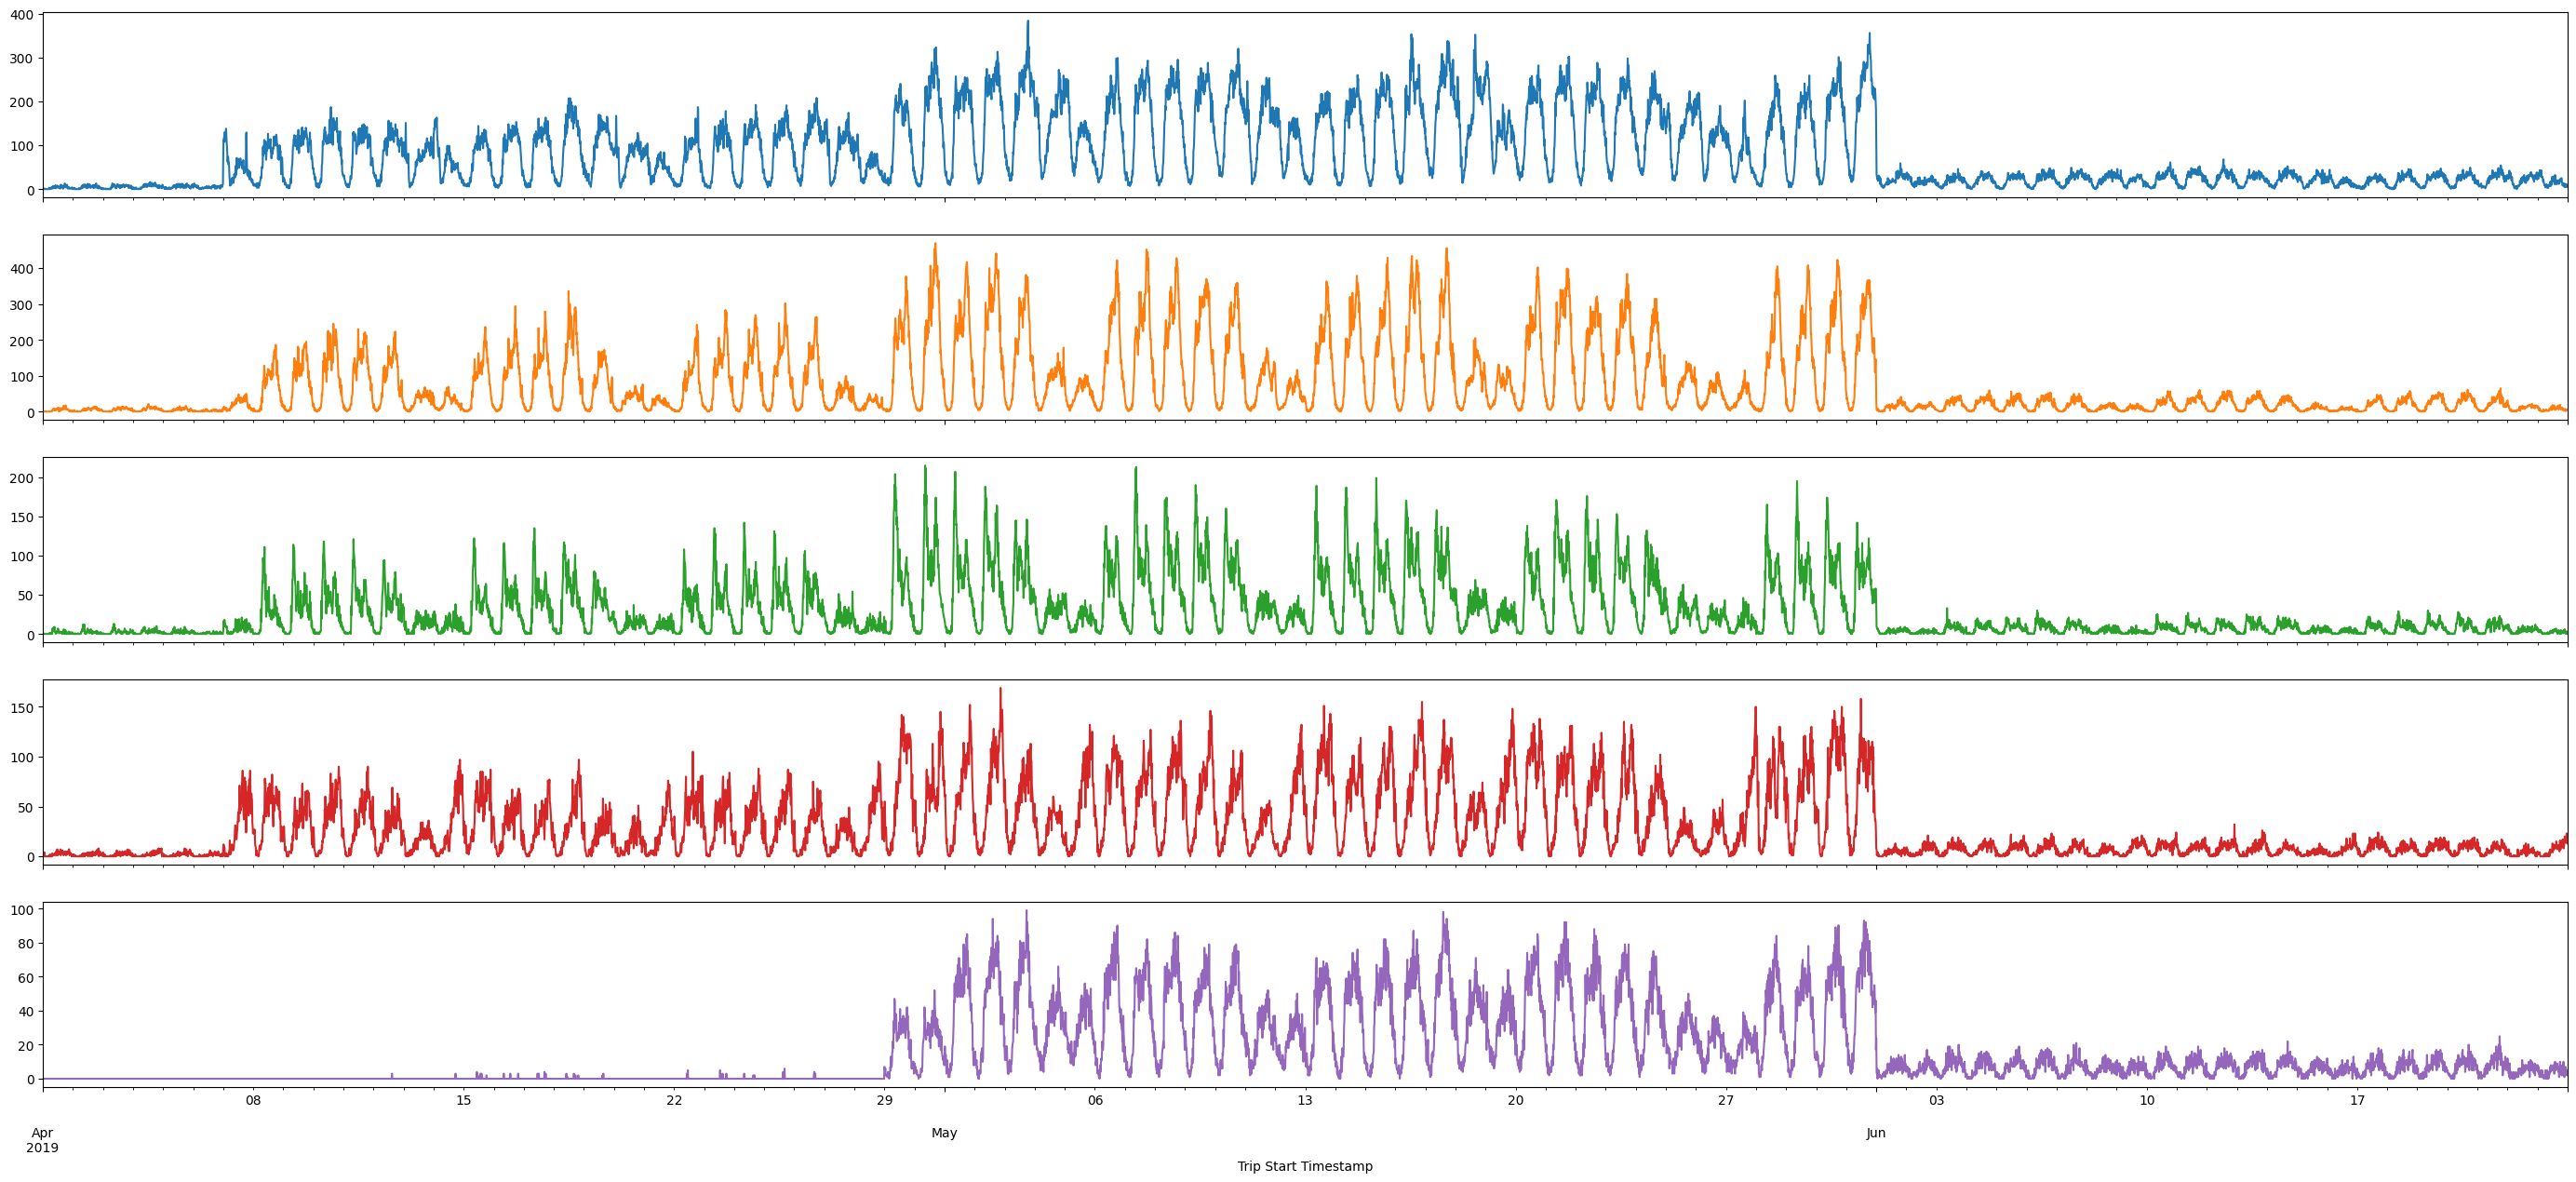

In [107]:
df[['Trip Start Timestamp', 'Pickup Community Area_8',
       'Pickup Community Area_32', 'Pickup Community Area_28',
       'Pickup Community Area_76', 'Pickup Community Area_0']].plot(x="Trip Start Timestamp", kind='line', subplots=True, figsize=(35,15),legend=False);

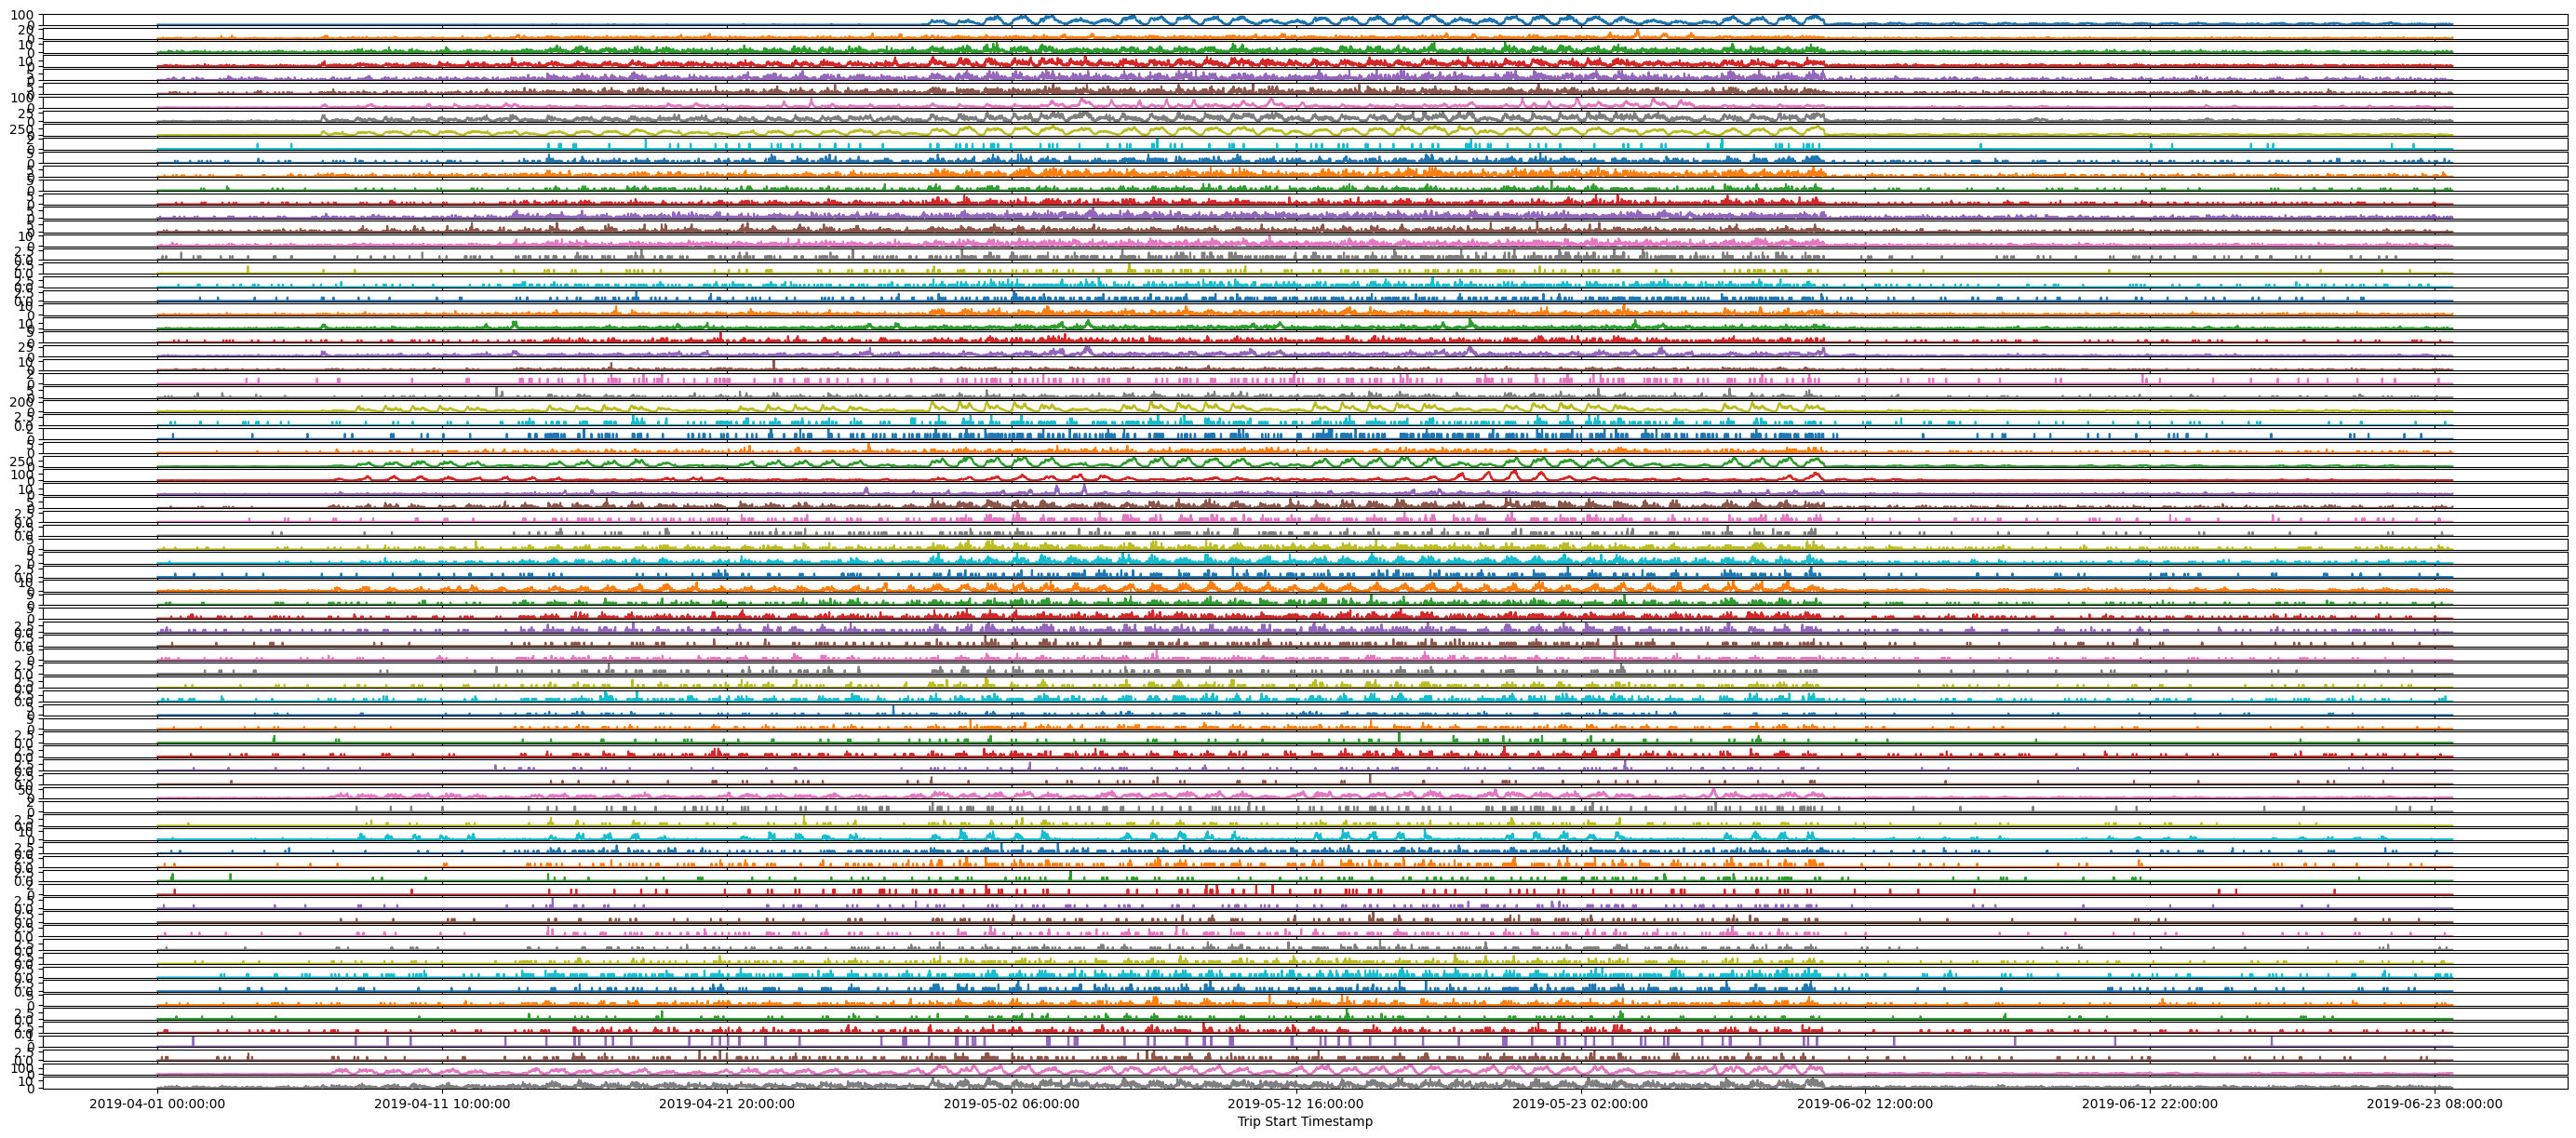

In [28]:
df.plot(x="Trip Start Timestamp", kind='line', subplots=True, figsize=(35,15),legend=False);

In [4]:
horizon = 673
n = df.shape[0]

date_col = "Trip Start Timestamp"
area_cols = df.columns.drop(date_col)

df[date_col] = df[date_col].astype('datetime64[ns]')

test = df.iloc[n - horizon:]
val  = df.iloc[n - horizon - horizon:n - horizon]
train = df.iloc[: n - horizon - horizon]

n_val = len(val)

In [53]:
pd.to_datetime(df[date_col]).dt.month.unique()

array([4, 5, 6], dtype=int32)

In [9]:
print(len(train), len(val), len(test))
print(train["Trip Start Timestamp"].min(), "->", train["Trip Start Timestamp"].max())
print(val["Trip Start Timestamp"].min(), "->", val["Trip Start Timestamp"].max())
print(test["Trip Start Timestamp"].min(), "->", test["Trip Start Timestamp"].max())

6718 673 673
2019-04-01 00:00:00 -> 2019-06-09 23:15:00
2019-06-09 23:30:00 -> 2019-06-16 23:30:00
2019-06-16 23:45:00 -> 2019-06-23 23:45:00


# Naive averages

Mean MAE over all areas: 3.392
Pickup Community Area_8     74.211
Pickup Community Area_32    71.555
Pickup Community Area_76    28.113
Pickup Community Area_28    26.590
Pickup Community Area_0     10.996
dtype: float64


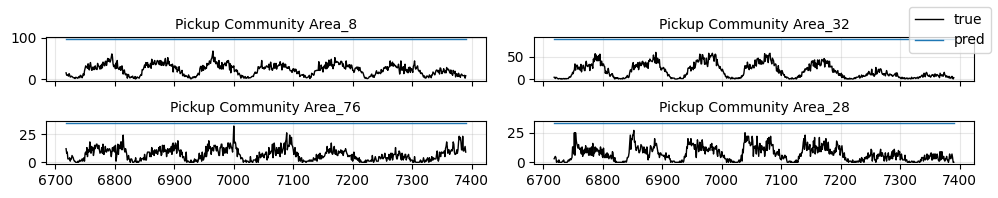

In [35]:
# 1. Наивный прогноз: среднее значение по train отдельно для каждой зоны
naive_means = train[area_cols].mean(axis=0)

# 2. Строим прогноз для val:
#    для каждого временного шага в val используем одни и те же средние по зонам
y_val_pred = pd.DataFrame(
    np.tile(naive_means.values, (len(val), 1)),  # повторяем в строках
    columns=area_cols,
    index=val.index,
)

# 3. Реальные значения на валидации
y_val_true = val[area_cols]

# 4. MAE по каждой зоне и среднее MAE
mae_per_area = (y_val_true - y_val_pred).abs().mean(axis=0)  # по времени
mae_mean = mae_per_area.mean()  # усреднение по зонам

print("Mean MAE over all areas:", round(mae_mean,3))

# посмотреть топ-5 зон с худшим MAE
print(mae_per_area.sort_values(ascending=False).head().round(3))
utils.plot_true_vs_pred_subplots(y_val_true, y_val_pred, mae_per_area.sort_values(ascending=False)[:4].index.to_list(), figsize=(10, 2))

# Moving averages

Moving Average mean MAE over all areas: 0.666
Pickup Community Area_32    13.676
Pickup Community Area_8     11.160
Pickup Community Area_28     4.873
Pickup Community Area_76     4.398
Pickup Community Area_0      3.661
dtype: float64


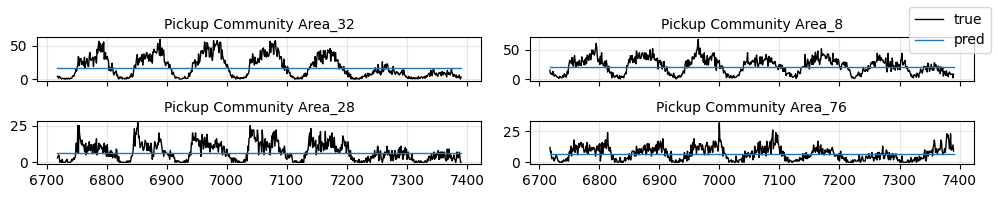

In [5]:
# словарь для MA прогнозов по районам
ma_val_forecasts = {}

for col in area_cols:
    y_train = train[col]

    # скользящее среднее
    rolling_mean = y_train.rolling(window=horizon, min_periods=1).mean()

    # последнее доступное значение rolling mean на train
    last_ma = rolling_mean.iloc[-1]

    # прогноз на валидацию: константа last_ma на все 673 точек
    ma_val_forecasts[col] = np.full(shape=horizon, fill_value=last_ma, dtype=float)

# собираем прогнозы в DataFrame
ma_val_pred = pd.DataFrame(ma_val_forecasts, index=val.index)

# фактические значения
y_val_true = val[area_cols]

# MAE по каждой зоне и среднее MAE
ma_mae_per_area = (y_val_true - ma_val_pred).abs().mean(axis=0)
ma_mae_mean = ma_mae_per_area.mean()

print("Moving Average mean MAE over all areas:", round(ma_mae_mean,3))

print(ma_mae_per_area.sort_values(ascending=False).head().round(3))
utils.plot_true_vs_pred_subplots(y_val_true, ma_val_pred, ma_mae_per_area.sort_values(ascending=False)[:4].index.to_list(), figsize=(10, 2))

# Exponential Smoothing

In [6]:
# словари для прогнозов по каждому типу модели
ses_val_forecasts = {}
holt_val_forecasts = {}
hw_val_forecasts = {}

# для хранения MAE по зонам
ses_mae = {}
holt_mae = {}
hw_mae = {}

for col in area_cols:
    y_train = train[col].values

    # 1) Simple Exponential Smoothing
    ses_model = SimpleExpSmoothing(y_train).fit(optimized=True)
    ses_forecast = ses_model.forecast(n_val)
    ses_val_forecasts[col] = ses_forecast

    # 2) Holt (линейный тренд)
    holt_model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal=None
    ).fit(optimized=True)
    holt_forecast = holt_model.forecast(n_val)
    holt_val_forecasts[col] = holt_forecast

    # 3) Holt–Winters (аддитивная сезонность, период = 96 шагов = 1 день)
    hw_model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=96
    ).fit(optimized=True)
    hw_forecast = hw_model.forecast(n_val)
    hw_val_forecasts[col] = hw_forecast

# Приводим к DataFrame
ses_val_pred = pd.DataFrame(ses_val_forecasts, index=val.index)
holt_val_pred = pd.DataFrame(holt_val_forecasts, index=val.index)
hw_val_pred = pd.DataFrame(hw_val_forecasts, index=val.index)

y_val_true = val[area_cols]

# MAE по районам и среднее MAE
ses_mae_per_area = mean_absolute_error(
    y_val_true, ses_val_pred, multioutput="raw_values"
)
holt_mae_per_area = mean_absolute_error(
    y_val_true, holt_val_pred, multioutput="raw_values"
)
hw_mae_per_area = mean_absolute_error(
    y_val_true, hw_val_pred, multioutput="raw_values"
)

# Превратим в Series с именами колонок
ses_mae_per_area = pd.Series(ses_mae_per_area, index=area_cols, name="SES_MAE")
holt_mae_per_area = pd.Series(holt_mae_per_area, index=area_cols, name="Holt_MAE")
hw_mae_per_area = pd.Series(hw_mae_per_area, index=area_cols, name="HW_MAE")

# Средние MAE по всем районам
ses_mae_mean = ses_mae_per_area.mean()
holt_mae_mean = holt_mae_per_area.mean()
hw_mae_mean = hw_mae_per_area.mean()

print("SES mean MAE:", ses_mae_mean)
print("Holt mean MAE:", holt_mae_mean)
print("Holt-Winters mean MAE:", hw_mae_mean)

SES mean MAE: 0.7859875688102944
Holt mean MAE: 7.437946134653375
Holt-Winters mean MAE: 1.6657850113813033


In [8]:
mae_table = pd.concat([ses_mae_per_area, holt_mae_per_area, hw_mae_per_area], axis=1)
print(mae_table.sort_values(by='SES_MAE', ascending=False).head())

                            SES_MAE    Holt_MAE     HW_MAE
Pickup Community Area_8   16.285093  429.609715  15.661822
Pickup Community Area_32  14.797029   79.713055  33.523497
Pickup Community Area_28   6.261375    6.240435   8.359847
Pickup Community Area_76   4.633834    4.748068   4.997586
Pickup Community Area_0    3.680397   20.170960  39.349282


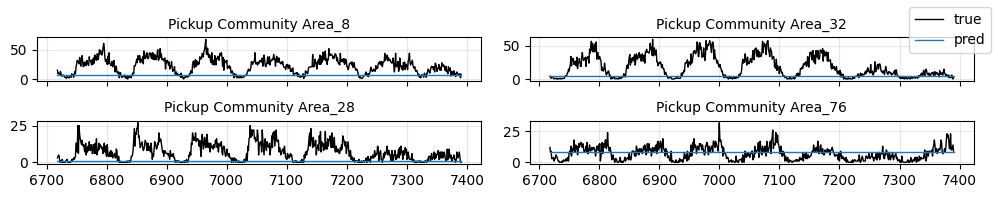

In [10]:
utils.plot_true_vs_pred_subplots(y_val_true, ses_val_pred, mae_table.sort_values(by='SES_MAE', ascending=False)[:4].index.to_list(), figsize=(10, 2))

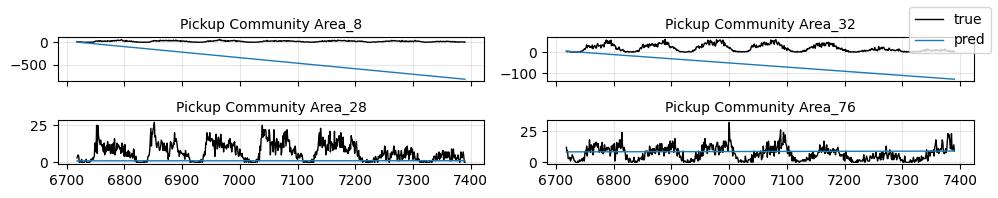

In [11]:
utils.plot_true_vs_pred_subplots(y_val_true, holt_val_pred, mae_table.sort_values(by='SES_MAE', ascending=False)[:4].index.to_list(), figsize=(10, 2))

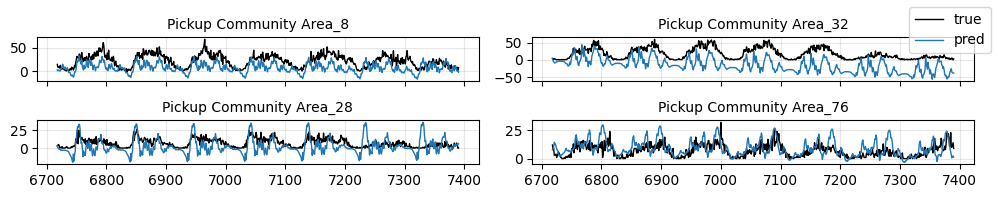

In [12]:
utils.plot_true_vs_pred_subplots(y_val_true, hw_val_pred, mae_table.sort_values(by='SES_MAE', ascending=False)[:4].index.to_list(), figsize=(10, 2))

In [13]:
# словарь для прогнозов по каждому району
hw_val_forecasts = {}

# цикл по районам
for col in area_cols:
    y_train = train[col].values

    # Holt–Winters: только сезонность, без тренда
    hw_model = ExponentialSmoothing(
        y_train,
        trend=None,
        seasonal="add",
        seasonal_periods=96
    ).fit(optimized=True)

    hw_forecast = hw_model.forecast(n_val)
    hw_val_forecasts[col] = hw_forecast

# wide-DataFrame с прогнозами на валидации
hw_val_pred = pd.DataFrame(hw_val_forecasts, index=val.index)

# истинные значения на валидации
y_val_true = val[area_cols]

# MAE по районам
hw_mae_per_area = mean_absolute_error(
    y_val_true,
    hw_val_pred,
    multioutput="raw_values"
)

# превратим в Series с именами районов
hw_mae_per_area = pd.Series(hw_mae_per_area, index=area_cols, name="HW_MAE")

# среднее MAE по всем районам
hw_mae_mean = hw_mae_per_area.mean()

print("Holt-Winters (seasonal only) mean MAE:", hw_mae_mean)

Holt-Winters (seasonal only) mean MAE: 1.0928636839934636


Pickup Community Area_32    16.612
Pickup Community Area_8     13.464
Pickup Community Area_28    11.306
Pickup Community Area_76    10.100
Pickup Community Area_33     6.448
Name: HW_MAE, dtype: float64


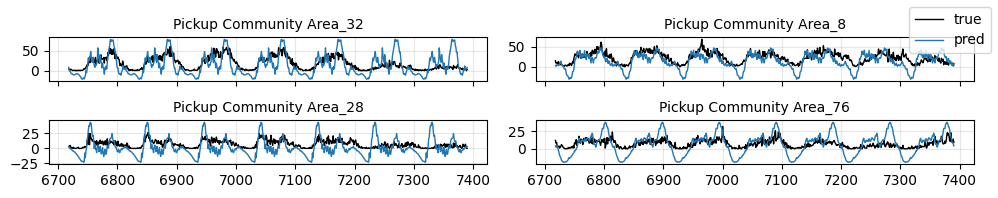

In [17]:
print(hw_mae_per_area.sort_values(ascending=False).head().round(3))
utils.plot_true_vs_pred_subplots(y_val_true, hw_val_pred, hw_mae_per_area.sort_values(ascending=False)[:4].index.to_list(), figsize=(10, 2))

# SARIMA

In [ ]:
# сюда сложим прогнозы на валидацию и тест
sarima_val_forecasts = {}

# сюда сложим информацию о моделях
sarima_info = []

for col in area_cols:
    print(f"Fitting SARIMA for area: {col}")

    y_train = train[col].values

    # авто-подбор SARIMA
    model = pm.auto_arima(
        y_train,
        start_p=0, start_q=0,
        max_p=2, max_q=2,
        d=None, 
        max_d=1,            
        seasonal=False,
        information_criterion="aic",
        stepwise=True,
        error_action="ignore",
        suppress_warnings=True,
        trace=False,
        scoring='mae'
    )

    # прогноз на val
    y_val_pred = model.predict(n_periods=n_val)

    sarima_val_forecasts[col] = y_val_pred

    # MAE на валидации
    y_val_true = val[col].values
    mae_val = mean_absolute_error(y_val_true, y_val_pred)

    # сохраняем сведения о модели
    sarima_info.append({
        "area": col,
        "order": model.order,
        "seasonal_order": model.seasonal_order,
        "AIC": model.aic(),
        "MAE_val": mae_val,
    })

# Прогнозы в DataFrame
sarima_val_pred_df = pd.DataFrame(sarima_val_forecasts, index=val.index)

# Средний MAE по всем районам
mae_per_area = mean_absolute_error(
    val[area_cols], sarima_val_pred_df[area_cols], multioutput="raw_values"
)
mae_mean = mae_per_area.mean()
print("SARIMA mean MAE over all areas:", mae_mean)

# Таблица с информацией о моделях
sarima_info_df = pd.DataFrame(sarima_info)

Fitting SARIMA for area: Pickup Community Area_0
Fitting SARIMA for area: Pickup Community Area_1
Fitting SARIMA for area: Pickup Community Area_2
Fitting SARIMA for area: Pickup Community Area_3
Fitting SARIMA for area: Pickup Community Area_4
Fitting SARIMA for area: Pickup Community Area_5
Fitting SARIMA for area: Pickup Community Area_6
Fitting SARIMA for area: Pickup Community Area_7
Fitting SARIMA for area: Pickup Community Area_8
Fitting SARIMA for area: Pickup Community Area_9
Fitting SARIMA for area: Pickup Community Area_10
Fitting SARIMA for area: Pickup Community Area_11
Fitting SARIMA for area: Pickup Community Area_12
Fitting SARIMA for area: Pickup Community Area_13
Fitting SARIMA for area: Pickup Community Area_14
Fitting SARIMA for area: Pickup Community Area_15
Fitting SARIMA for area: Pickup Community Area_16
Fitting SARIMA for area: Pickup Community Area_17
Fitting SARIMA for area: Pickup Community Area_18
Fitting SARIMA for area: Pickup Community Area_19
Fitting SA

                        area      order seasonal_order           AIC  \
8    Pickup Community Area_8  (1, 1, 1)   (0, 0, 0, 0)  56502.652094   
32  Pickup Community Area_32  (1, 1, 1)   (0, 0, 0, 0)  58480.617171   
28  Pickup Community Area_28  (1, 1, 0)   (0, 0, 0, 0)  51718.339711   
76  Pickup Community Area_76  (0, 1, 1)   (0, 0, 0, 0)  50255.752482   
0    Pickup Community Area_0  (1, 1, 1)   (0, 0, 0, 0)  41534.724040   

      MAE_val  
8   16.420845  
32  14.622957  
28   6.380506  
76   4.633780  
0    3.664936  


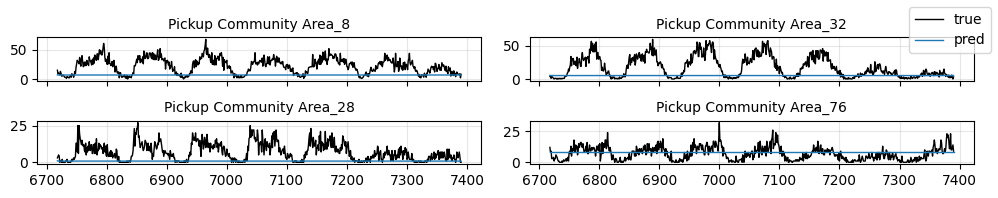

In [23]:
print(sarima_info_df.sort_values(by = 'MAE_val', ascending=False).head())
utils.plot_true_vs_pred_subplots(val[area_cols], sarima_val_pred_df, sarima_info_df.sort_values(by = 'MAE_val',ascending=False)[:4]['area'].to_list(), figsize=(10, 2))

# SARIMAX

In [70]:
df_X_train, df_X_val = utils.build_time_features(train), utils.build_time_features(val)

In [71]:
df_X_train.columns

Index(['Trip Start Timestamp', 'is_weekend', 'hbin_morning_peak', 'hbin_day',
       'hbin_evening_peak', 'hbin_late_evening', 'dow_1', 'dow_2', 'dow_3',
       'dow_4', 'dow_5', 'dow_6', 'fourier_sin_1', 'fourier_cos_1',
       'fourier_sin_2', 'fourier_cos_2'],
      dtype='object')

In [91]:
df_X_train[['is_weekend', 'dow_1', 'dow_2', 'dow_3',
       'dow_4', 'dow_5', 'dow_6']].sum()

is_weekend    1918
dow_1          960
dow_2          960
dow_3          960
dow_4          960
dow_5          960
dow_6          958
dtype: int64

In [92]:
X = df_X_train.drop(columns=["Trip Start Timestamp",'is_weekend'])
X_with_const = X.assign(const=1.0)
vif_data = []
for i, col in enumerate(X_with_const.columns):
    vif = variance_inflation_factor(X_with_const.values, i)
    vif_data.append((col, vif))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"])

In [93]:
vif_df

,feature,VIF
0,hbin_morning_peak,4.916956
1,hbin_day,15.923489
2,hbin_evening_peak,13.094680
3,hbin_late_evening,3.529900
4,dow_1,1.714201
5,dow_2,1.714201
6,dow_3,1.714201
7,dow_4,1.714201
8,dow_5,1.714201
9,dow_6,1.713017


In [95]:
X = df_X_train.drop(columns=["Trip Start Timestamp",'is_weekend','hbin_morning_peak','hbin_day','hbin_evening_peak','hbin_late_evening'])
X_with_const = X.assign(const=1.0)
vif_data = []
for i, col in enumerate(X_with_const.columns):
    vif = variance_inflation_factor(X_with_const.values, i)
    vif_data.append((col, vif))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"])

vif_df

,feature,VIF
0,dow_1,1.714201
1,dow_2,1.714201
2,dow_3,1.714201
3,dow_4,1.714201
4,dow_5,1.714201
5,dow_6,1.713012
6,fourier_sin_1,1.000000
7,fourier_cos_1,1.000001
8,fourier_sin_2,1.000000
9,fourier_cos_2,1.000001


In [106]:
X_cols = ['dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6',
       'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']

In [72]:
df_X_train.tail()

,Trip Start Timestamp,is_weekend,hbin_morning_peak,hbin_day,hbin_evening_peak,hbin_late_evening,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2
6713,2019-06-09 22:15:00,1,0,0,0,1,0,0,0,0,0,1,-0.442289,0.896873,-0.793353,0.608761
6714,2019-06-09 22:30:00,1,0,0,0,1,0,0,0,0,0,1,-0.382683,0.923880,-0.707107,0.707107
6715,2019-06-09 22:45:00,1,0,0,0,1,0,0,0,0,0,1,-0.321439,0.946930,-0.608761,0.793353
6716,2019-06-09 23:00:00,1,0,0,0,1,0,0,0,0,0,1,-0.258819,0.965926,-0.500000,0.866025
6717,2019-06-09 23:15:00,1,0,0,0,1,0,0,0,0,0,1,-0.195090,0.980785,-0.382683,0.923880


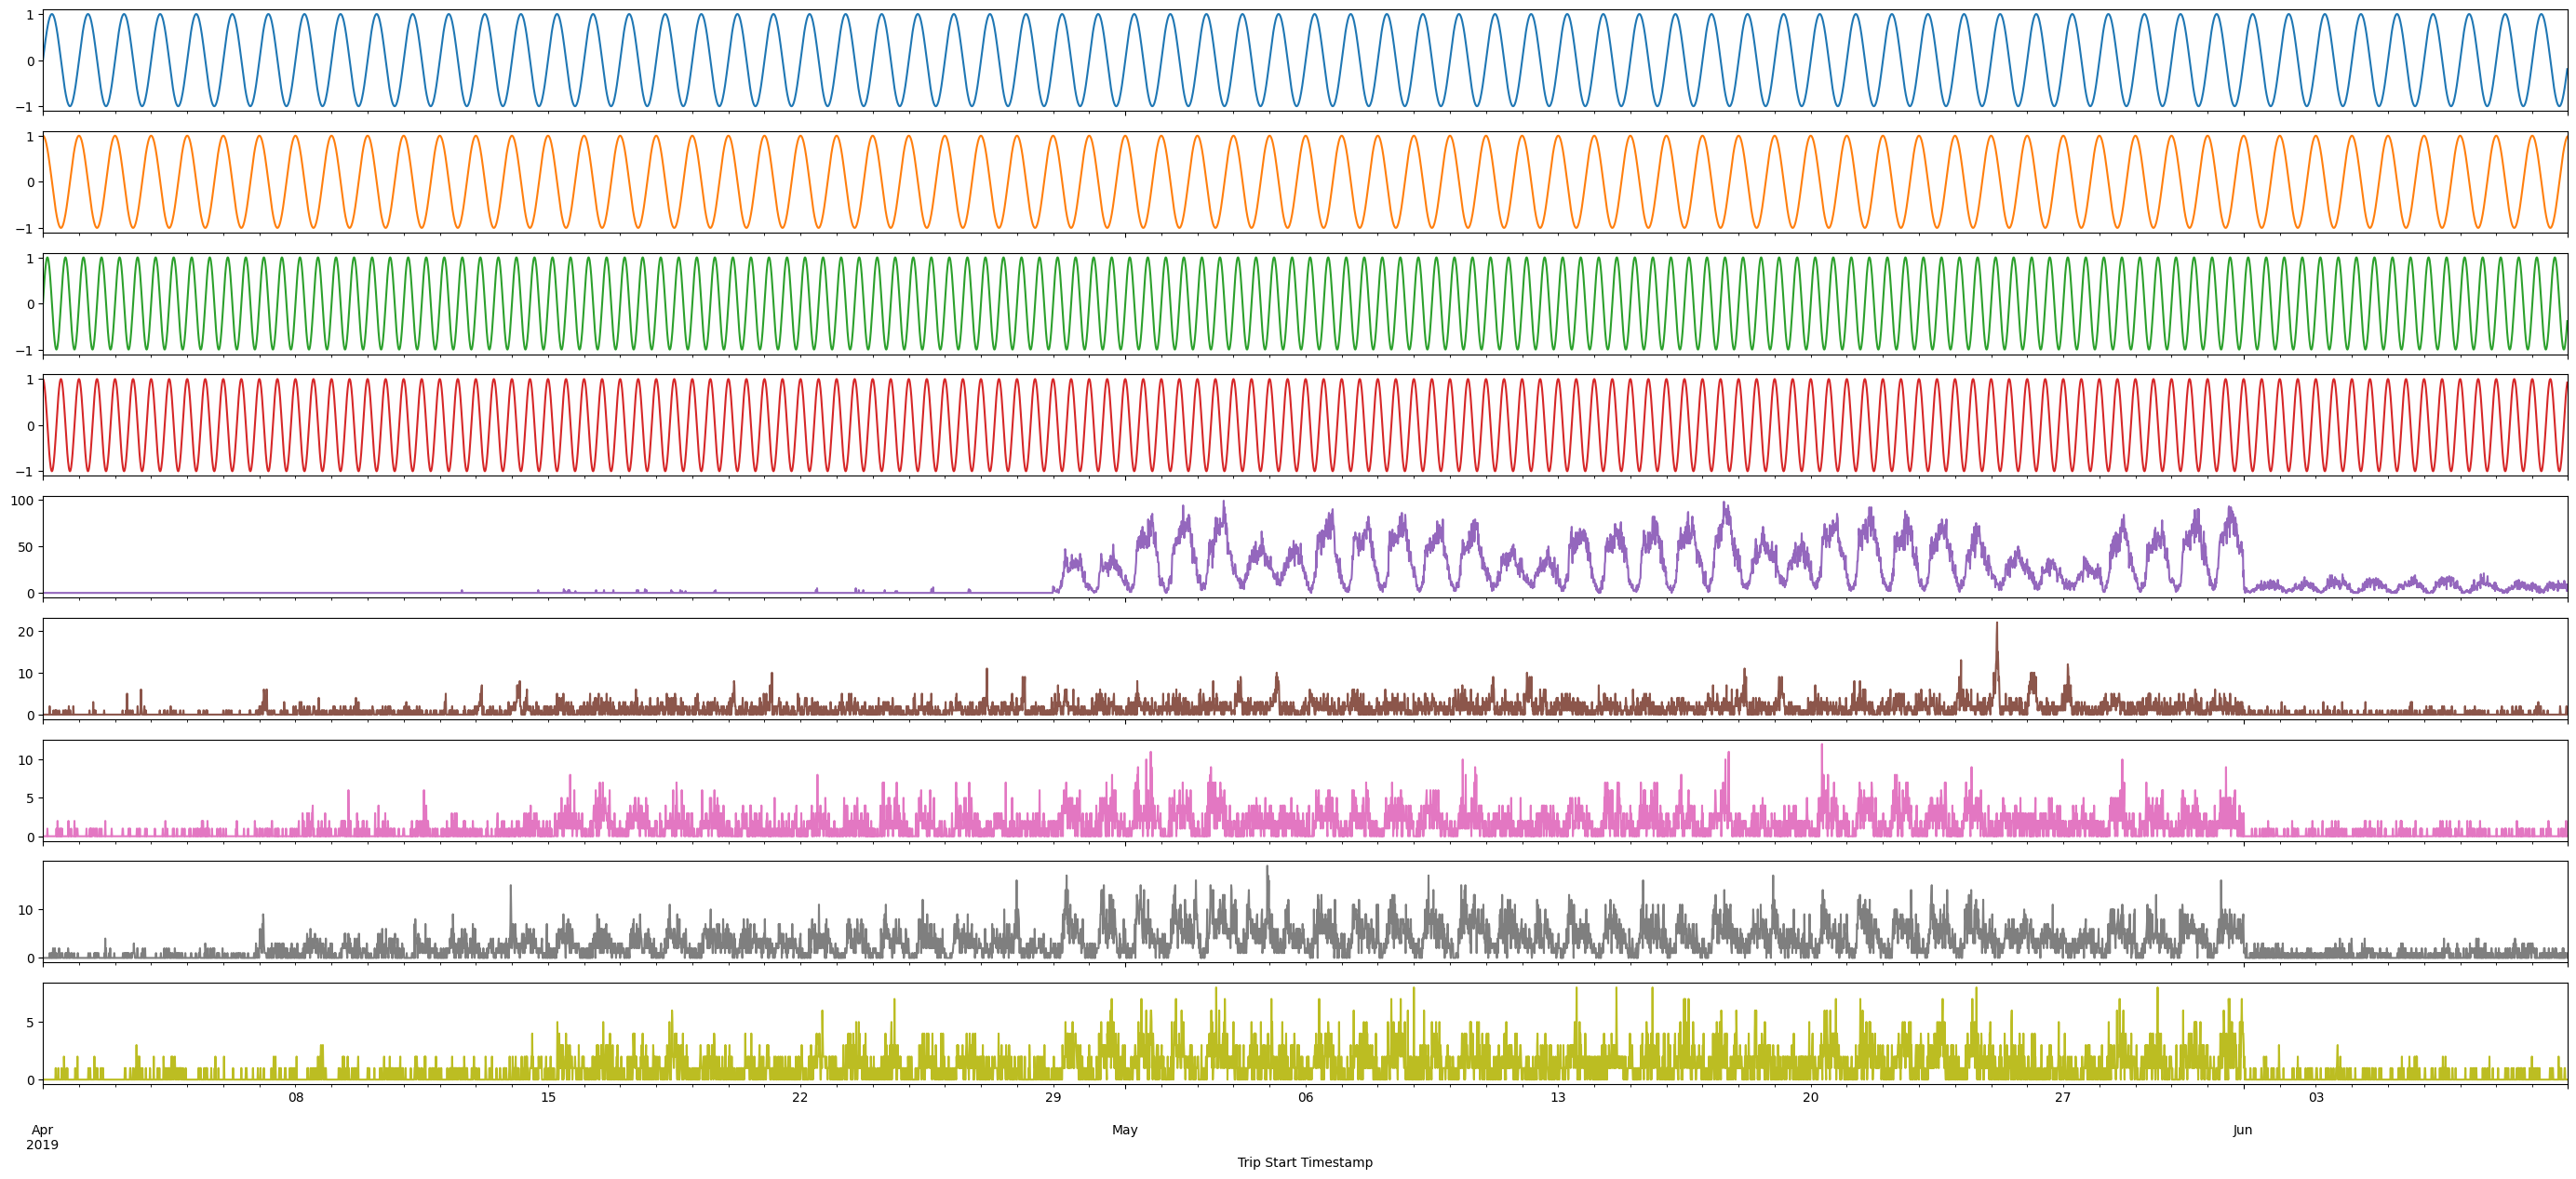

In [37]:
df_X_train.merge(train)[['fourier_sin_1','fourier_cos_1', 'fourier_sin_2',
       'fourier_cos_2','Trip Start Timestamp', 'Pickup Community Area_0',
       'Pickup Community Area_1', 'Pickup Community Area_2',
       'Pickup Community Area_3', 'Pickup Community Area_4']].plot(x="Trip Start Timestamp", kind='line', subplots=True, figsize=(35,15),legend=False);

In [104]:
# сюда сложим прогнозы на валидацию и тест
sarima_val_forecasts = {}

# сюда сложим информацию о моделях
sarima_info = []

for col in area_cols:
    print(f"Fitting SARIMAX for area: {col}")

    y_train = train[col].values

    # авто-подбор SARIMA
    model = pm.auto_arima(
        y_train,
        df_X_train[X_cols],
        start_p=0, start_q=0,
        max_p=1, max_q=1,
        d=1,     
        seasonal=False,
        information_criterion="aic",
        stepwise=True,
        error_action="ignore",
        suppress_warnings=True,
        trace=False,
        scoring='mae'
    )

    # прогноз на val
    y_val_pred = model.predict(n_periods=n_val, X=df_X_val[X_cols])

    sarima_val_forecasts[col] = y_val_pred

    # MAE на валидации
    y_val_true = val[col].values
    mae_val = mean_absolute_error(y_val_true, y_val_pred)

    # сохраняем сведения о модели
    sarima_info.append({
        "area": col,
        "order": model.order,
        "seasonal_order": model.seasonal_order,
        "AIC": model.aic(),
        "MAE_val": mae_val,
    })

# Прогнозы в DataFrame
sarimax_val_pred_df = pd.DataFrame(sarima_val_forecasts, index=val.index)

# Средний MAE по всем районам
sarimax_mae_per_area = mean_absolute_error(
    val[area_cols], sarimax_val_pred_df[area_cols], multioutput="raw_values"
)
sarimax_mae_mean = sarimax_mae_per_area.mean()
print("SARIMA mean MAE over all areas:", sarimax_mae_mean)

# Таблица с информацией о моделях
sarimax_info_df = pd.DataFrame(sarima_info)

Fitting SARIMAX for area: Pickup Community Area_0
Fitting SARIMAX for area: Pickup Community Area_1
Fitting SARIMAX for area: Pickup Community Area_2
Fitting SARIMAX for area: Pickup Community Area_3
Fitting SARIMAX for area: Pickup Community Area_4
Fitting SARIMAX for area: Pickup Community Area_5
Fitting SARIMAX for area: Pickup Community Area_6
Fitting SARIMAX for area: Pickup Community Area_7
Fitting SARIMAX for area: Pickup Community Area_8
Fitting SARIMAX for area: Pickup Community Area_9
Fitting SARIMAX for area: Pickup Community Area_10
Fitting SARIMAX for area: Pickup Community Area_11
Fitting SARIMAX for area: Pickup Community Area_12
Fitting SARIMAX for area: Pickup Community Area_13
Fitting SARIMAX for area: Pickup Community Area_14
Fitting SARIMAX for area: Pickup Community Area_15
Fitting SARIMAX for area: Pickup Community Area_16
Fitting SARIMAX for area: Pickup Community Area_17
Fitting SARIMAX for area: Pickup Community Area_18
Fitting SARIMAX for area: Pickup Communit

                        area      order seasonal_order           AIC  \
32  Pickup Community Area_32  (1, 1, 1)   (0, 0, 0, 0)  58130.804902   
8    Pickup Community Area_8  (0, 1, 1)   (0, 0, 0, 0)  56149.162292   
28  Pickup Community Area_28  (1, 1, 1)   (0, 0, 0, 0)  51627.887407   
76  Pickup Community Area_76  (1, 1, 1)   (0, 0, 0, 0)  49951.806574   
33  Pickup Community Area_33  (1, 1, 1)   (0, 0, 0, 0)  40420.262279   

      MAE_val  
32  47.782661  
8   29.436293  
28  15.700339  
76  15.356564  
33   8.189764  


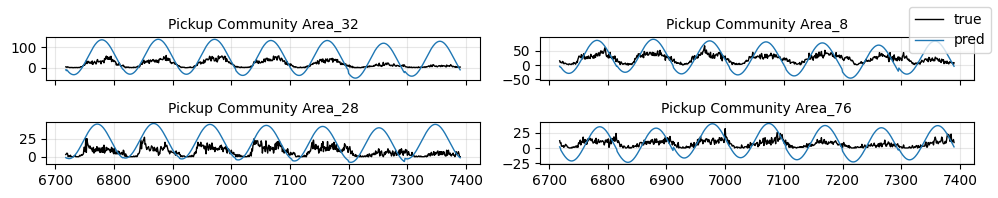

In [105]:
print(sarimax_info_df.sort_values(by = 'MAE_val', ascending=False).head())
utils.plot_true_vs_pred_subplots(val[area_cols], sarimax_val_pred_df, sarimax_info_df.sort_values(by = 'MAE_val',ascending=False)[:4]['area'].to_list(), figsize=(10, 2))

# Check best model on test dataset

In [18]:
# словарь для прогнозов по каждому району
hw_test_forecasts = {}

# цикл по районам
for col in area_cols:
    y_train = train[col].values

    # Holt–Winters: только сезонность, без тренда
    hw_model = ExponentialSmoothing(
        y_train,
        trend=None,
        seasonal="add",
        seasonal_periods=96
    ).fit(optimized=True)

    hw_forecast = hw_model.forecast(n_val)
    hw_test_forecasts[col] = hw_forecast

# wide-DataFrame с прогнозами на валидации
hw_test_pred = pd.DataFrame(hw_test_forecasts, index=test.index)

# истинные значения на валидации
y_test_true = test[area_cols]

# MAE по районам
hw_mae_per_area = mean_absolute_error(
    y_test_true,
    hw_test_pred,
    multioutput="raw_values"
)

# превратим в Series с именами районов
hw_mae_per_area = pd.Series(hw_mae_per_area, index=area_cols, name="HW_MAE")

# среднее MAE по всем районам
hw_mae_mean = hw_mae_per_area.mean()

print("Holt-Winters (seasonal only) mean MAE:", hw_mae_mean)

Holt-Winters (seasonal only) mean MAE: 1.0777013923091652


Pickup Community Area_32    16.641
Pickup Community Area_8     12.609
Pickup Community Area_28    11.127
Pickup Community Area_76     9.926
Pickup Community Area_33     6.226
Name: HW_MAE, dtype: float64


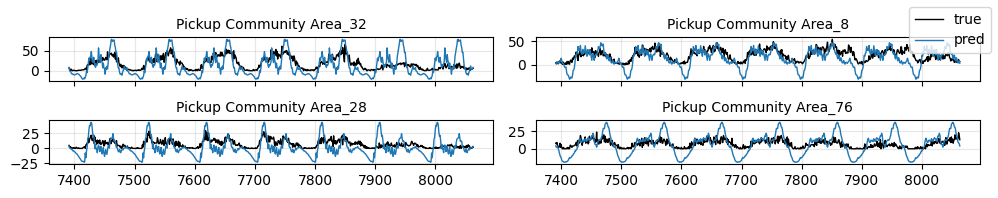

In [19]:
print(hw_mae_per_area.sort_values(ascending=False).head().round(3))
utils.plot_true_vs_pred_subplots(y_test_true, hw_test_pred, hw_mae_per_area.sort_values(ascending=False)[:4].index.to_list(), figsize=(10, 2))